In [6]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
matplotlib.use('Agg')
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [3]:
n = pypsa.Network("../external/pypsa-eur/resources/nl20/networks/base_s_20_elec.nc")
#n.plot()

INFO:pypsa.network.io:New version 1.2.1 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


INFO:pypsa.network.io:New version 1.2.1 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, loads, sub_networks


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x1ee32f2a3c0>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x1ee32f2a510>},
 'flows': {}}

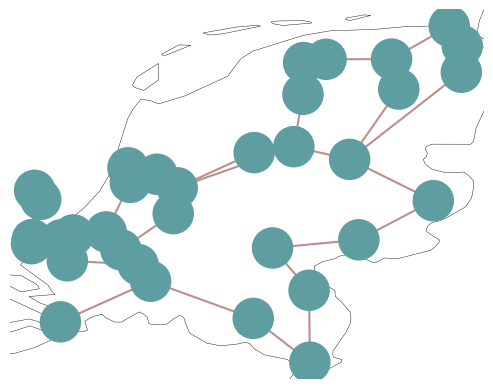

In [4]:
n34 = pypsa.Network("../external/pypsa-eur/resources/nl34/networks/base_s_34_elec.nc")
n34.plot()

INFO:pypsa.network.io:New version 1.2.1 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x1ee334bd1d0>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x1ee334bd450>,
  'Line': <matplotlib.collections.LineCollection at 0x1ee334bd310>},
 'flows': {}}

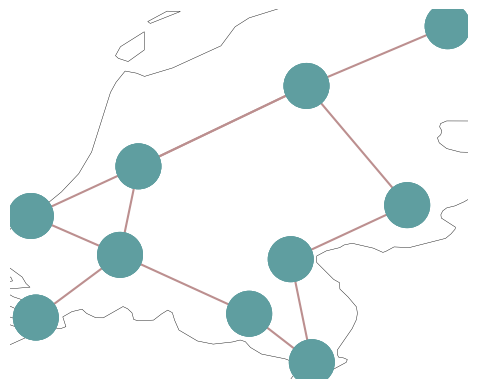

In [5]:
n10 = pypsa.Network("../external/pypsa-eur/resources/nl10/networks/base_s_10_elec.nc")
n10.plot()

In [6]:
# delete H2 and battery buses
n.buses = n.buses[~n.buses.index.isin(n.buses[n.buses.carrier == "H2"].index) & ~n.buses.index.isin(n.buses[n.buses.carrier == "battery"].index)]
n.buses.to_csv("nl20_buses.csv")
n.lines.to_csv("nl20_lines.csv")
# delete generators with zero capacity
n.generators = n.generators[n.generators.p_nom > 0]
n.generators.to_csv("nl20_generators.csv")

lines20 = pd.read_csv("nl20_lines.csv")
lines20_cap = sum(lines20["s_nom"])
print(lines20_cap)

gens20 = pd.read_csv("nl20_generators.csv")
gens20_cap = sum(gens20["p_nom"])
print(gens20_cap)

83743.27568182812
39558.8


In [7]:
# delete H2 and battery buses
n10.buses = n10.buses[~n10.buses.index.isin(n10.buses[n10.buses.carrier == "H2"].index) & ~n10.buses.index.isin(n10.buses[n10.buses.carrier == "battery"].index)]
n10.buses.to_csv("nl20_buses.csv")
n10.lines.to_csv("nl10_lines.csv")
# delete generators with zero capacity
n10.generators = n10.generators[n10.generators.p_nom > 0]
n10.generators.to_csv("nl20_generators.csv")

lines10 = pd.read_csv("nl10_lines.csv")
lines10_cap = sum(lines10["s_nom"])
print(lines10_cap)

gens10 = pd.read_csv("nl10_generators.csv")
gens10_cap = sum(gens10["p_nom"])
print(gens10_cap)

47814.999370265374
39558.8


In [8]:
# delete H2 and battery buses
n34.buses = n34.buses[~n34.buses.index.isin(n34.buses[n34.buses.carrier == "H2"].index) & ~n34.buses.index.isin(n34.buses[n34.buses.carrier == "battery"].index)]
n34.buses.to_csv("nl34_buses.csv")
n34.lines.to_csv("nl34_lines.csv")
# delete generators with zero capacity
n34.generators = n34.generators[n34.generators.p_nom > 0]
n34.generators.to_csv("nl34_generators.csv")

lines34 = pd.read_csv("nl34_lines.csv")
lines34_cap = sum(lines34["s_nom"])
print(lines34_cap)

gens34 = pd.read_csv("nl34_generators.csv")
gens34_cap = sum(gens34["p_nom"])
print(gens34_cap)

114890.05253401621
39558.8


In [9]:
print(n.loads.shape)
print(n.loads_t.p_set.shape)

print(n.generators.shape)
print(n.generators_t.p_max_pu.shape)

print(n.generators.carrier.unique())

print(n34.loads.shape)
print(n34.loads_t.p_set.shape)

print(n34.generators.shape)
print(n34.generators_t.p_max_pu.shape)

print(n34.generators.carrier.unique())

(20, 7)
(8760, 20)
(81, 42)
(8760, 94)
['CCGT' 'biomass' 'coal' 'waste' 'nuclear' 'offwind-ac' 'solar' 'onwind']
(32, 7)
(8760, 32)
(105, 42)
(8760, 93)
['CCGT' 'biomass' 'waste' 'coal' 'nuclear' 'solar' 'offwind-ac' 'onwind']


In [10]:
# map each load to its bus
load_to_bus = n.loads["bus"]

# load time series for each load component
load_ts = n.loads_t.p_set.copy()

# aggregate from loads to buses
load_per_bus = load_ts.T.groupby(load_to_bus).sum().T

load_per_bus.to_csv("nl20_load_timeseries_per_bus.csv")

print(load_per_bus.shape)
load_per_bus.head()

(8760, 20)


bus,NL0 0,NL0 1,NL0 10,NL0 11,NL0 12,NL0 13,NL0 14,NL0 15,NL0 16,NL0 17,NL0 18,NL0 19,NL0 2,NL0 3,NL0 4,NL0 5,NL0 6,NL0 7,NL0 8,NL0 9
snapshot,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,721.880814,563.071976,363.851158,345.225960,655.293144,633.312424,333.819229,558.444000,278.373344,533.591141,660.634796,117.232887,286.896240,283.186996,1005.177338,721.722000,775.122482,287.543884,704.243286,771.376892
2013-01-01 01:00:00,684.492828,533.909096,345.006416,327.345863,621.353905,600.511620,316.529907,529.520821,263.955711,505.955147,626.418900,111.161110,272.037178,268.520050,953.116737,684.342247,734.976982,272.651283,667.768799,731.425392
2013-01-01 02:00:00,648.262589,505.649254,326.745209,310.019424,588.465607,568.726509,299.775963,501.493248,249.984520,479.174919,593.262512,105.277351,257.638237,254.307266,902.668221,648.119972,696.074615,258.219833,632.423752,692.711006
2013-01-01 03:00:00,625.720840,488.066544,315.383438,299.239258,568.003151,548.950432,289.351982,484.055046,241.291916,462.512779,572.633255,101.616585,248.679497,245.464348,871.280128,625.583183,671.870316,249.240868,610.432755,668.623672
2013-01-01 04:00:00,621.430420,484.719978,313.220924,297.187439,564.108482,545.186401,287.367966,480.735992,239.637428,459.341431,568.706841,100.919823,246.974358,243.781258,865.305962,621.293701,667.263458,247.531883,606.247162,664.039070


In [11]:
# map each load to its bus
load_to_bus10 = n10.loads["bus"]

# load time series for each load component
load_ts10 = n10.loads_t.p_set.copy()

# aggregate from loads to buses
load_per_bus10 = load_ts10.T.groupby(load_to_bus10).sum().T

load_per_bus10.to_csv("nl10_load_timeseries_per_bus.csv")

print(load_per_bus10.shape)
load_per_bus10.head()

(8760, 10)


bus,NL0 0,NL0 1,NL0 2,NL0 3,NL0 4,NL0 5,NL0 6,NL0 7,NL0 8,NL0 9
snapshot,,,,,,,,,,
2013-01-01 00:00:00,721.722000,697.670387,2224.256134,908.297935,771.376892,1722.673119,987.587433,775.122482,942.189384,849.104225
2013-01-01 01:00:00,684.342247,661.536324,2109.056458,861.254959,731.425392,1633.451653,936.437851,734.976982,893.391083,805.127045
2013-01-01 02:00:00,648.119972,626.521172,1997.423981,815.668678,692.711006,1546.992981,886.872139,696.074615,846.103844,762.511620
2013-01-01 03:00:00,625.583183,604.735420,1927.968430,787.305801,668.623672,1493.200073,856.033318,671.870316,816.682648,735.997131
2013-01-01 04:00:00,621.293701,600.588890,1914.748795,781.907417,664.039070,1482.961533,850.163704,667.263458,811.082840,730.950569


In [19]:
# map each load to its bus
load_to_bus34 = n34.loads["bus"]

# load time series for each load component
load_ts34 = n34.loads_t.p_set.copy()

load_ts34.to_csv("nl34_load_timeseries_per_bus.csv")

ld34 = pd.read_csv("nl34_load_timeseries_per_bus.csv", index_col=0)

# node 29 and 32 were excluded from nodal load, they are offshore nodes with no load, but the columns need to exist with zero values
ld34["NL0 29"] = 0
ld34["NL0 32"] = 0

ld34.to_csv("nl34_load_timeseries_per_bus.csv")
print(ld34.shape)
ld34.head()

(8760, 34)


,NL0 0,NL0 1,NL0 10,NL0 11,NL0 12,NL0 13,NL0 14,NL0 15,NL0 16,NL0 17,...,NL0 31,NL0 33,NL0 4,NL0 5,NL0 6,NL0 7,NL0 8,NL0 9,NL0 29,NL0 32
snapshot,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,513.263779,306.811989,607.790970,334.414230,164.002419,602.277458,84.913925,260.276100,260.420532,372.694572,...,26.163528,0.029953,122.276657,708.969597,712.412148,663.331963,204.572266,263.685249,0,0
2023-01-01 01:00:00,503.334274,300.876465,596.032761,327.944717,160.829659,590.625908,83.271194,255.240845,255.382484,365.484497,...,25.657379,0.029373,119.911118,695.254005,698.629959,650.499275,200.614647,258.584045,0,0
2023-01-01 02:00:00,489.762238,292.763557,579.961182,319.101929,156.493004,574.700127,81.025848,248.358467,248.496292,355.629478,...,24.965546,0.028580,116.677803,676.506996,679.791924,632.959045,195.205223,251.611519,0,0
2023-01-01 03:00:00,481.305634,287.708481,569.947128,313.592072,153.790878,564.776917,79.626793,244.070122,244.205566,349.488907,...,24.534470,0.028084,114.663155,664.825912,668.054115,622.029892,191.834663,247.267006,0,0
2023-01-01 04:00:00,478.388947,285.964981,566.493286,311.691727,152.858917,561.354401,79.144264,242.591072,242.725693,347.371025,...,24.385796,0.027916,113.968300,660.797104,664.005745,618.260429,190.672150,245.768585,0,0


In [8]:
# aggregate load time series
total_load = load_ts.sum(axis=1)
total_load = total_load.rename("load")
total_load.to_csv("nl20_total_load_timeseries.csv")

In [13]:
# aggregate load time series
total_load = load_ts10.sum(axis=1)
total_load = total_load.rename("load")
total_load.to_csv("nl10_total_load_timeseries.csv")

In [12]:
# aggregate load time series
total_load = load_ts34.sum(axis=1)
total_load = total_load.rename("load")
total_load.to_csv("nl34_total_load_timeseries.csv")

In [12]:
# legacy generators are the generators already in the system, that do not have a investment decision (Renewables, waste, nuclear, biomass) - coal is not included anymore
legacy_gens = n.generators[n.generators.carrier.isin(["biomass", "waste", "nuclear", "solar", "onwind", "offwind-ac"])]
legacy_gens.to_csv("nl20_legacy_generators.csv")

In [ ]:
df = pd.read_csv("nl20_load_timeseries_per_bus_poc.csv")
# get rid of everything after the fourth column
df = df.iloc[:, :4]
df.columns = df.columns[:4]
df.iloc[:, 1] = 0
df.iloc[:, 2] = 60
df.iloc[:, -1] = 75
df.to_csv(r"nl20_load_timeseries_per_bus_poc.csv", index=False)

df_tot = df.copy()
df_tot["load"] = df.iloc[:, 1:].sum(axis=1)
df_tot = df_tot.iloc[:, [0, -1]]
df_tot.to_csv(r"nl20_total_load_timeseries_poc.csv", index=False)

In [15]:
# legacy generators are the generators already in the system, that do not have a investment decision (Renewables, waste, nuclear, biomass) - coal is not included anymore
legacy_gens = n10.generators[n10.generators.carrier.isin(["biomass", "waste", "nuclear", "solar", "onwind", "offwind-ac"])]
legacy_gens.to_csv("nl10_legacy_generators.csv")

In [14]:
# legacy generators are the generators already in the system, that do not have a investment decision (Renewables, waste, nuclear, biomass) - coal is not included anymore
legacy_gens = n34.generators[n34.generators.carrier.isin(["biomass", "waste", "nuclear", "solar", "onwind", "offwind-ac"])]
legacy_gens.to_csv("nl34_legacy_generators.csv")

In [15]:
# every node apart from 19 (offshore) gets a dummy CCGT plant with a capacity of 1000MW and average variable costs from the generator dataset
rows = []
exclude_buses = ["NL0 19"]  
for bus in n.buses.index:
    if bus not in exclude_buses: 
        rows.append({"name": f"{bus} CCGT", "bus": bus, "carrier": "CCGT", "p_nom": 1000,
                     "marginal_cost": n.generators[n.generators.carrier == "CCGT"].marginal_cost.mean()})

investable_gens = pd.DataFrame(rows)
investable_gens.to_csv("nl20_investable_generators.csv", index=False)

In [16]:
# every node apart from 29 and 32 (offshore) gets a dummy CCGT plant with a capacity of 1000MW and average variable costs from the generator dataset
rows = []
exclude_buses = ["NL0 29", "NL0 32"]  
for bus in n34.buses.index:
    if bus not in exclude_buses: 
        rows.append({"name": f"{bus} CCGT", "bus": bus, "carrier": "CCGT", "p_nom": 1000,
                     "marginal_cost": n34.generators[n34.generators.carrier == "CCGT"].marginal_cost.mean()})

investable_gens = pd.DataFrame(rows)
investable_gens.to_csv("nl34_investable_generators.csv", index=False)

In [19]:
rows = []
exclude_buses = []  
for bus in n10.buses.index:
    if bus not in exclude_buses: 
        rows.append({"name": f"{bus} CCGT", "bus": bus, "carrier": "CCGT", "p_nom": 2000,
                     "marginal_cost": n10.generators[n10.generators.carrier == "CCGT"].marginal_cost.mean()})

investable_gens = pd.DataFrame(rows)
investable_gens.to_csv("nl10_investable_generators.csv", index=False)

In [23]:
renewable_carriers = ['offwind-ac', 'solar', 'onwind']
renewable_generators = n.generators.index[
    n.generators["carrier"].isin(renewable_carriers)
]
cf_ts = n.generators_t.p_max_pu[renewable_generators]
cf_ts.to_csv("nl20_renewable_cf_per_generator.csv")

cf_ts.head()

name,NL0 1 0 offwind-ac,NL0 18 0 offwind-ac,NL0 19 0 offwind-ac,NL0 5 0 offwind-ac,NL0 7 0 offwind-ac,NL0 0 0 solar,NL0 1 0 solar,NL0 10 0 solar,NL0 11 0 solar,NL0 12 0 solar,...,NL0 18 0 onwind,NL0 19 0 onwind,NL0 2 0 onwind,NL0 3 0 onwind,NL0 4 0 onwind,NL0 5 0 onwind,NL0 6 0 onwind,NL0 7 0 onwind,NL0 8 0 onwind,NL0 9 0 onwind
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.885500,0.885500,0.885500,0.885500,0.885500,0.0,0.0,0.0,0.0,0.0,...,0.997914,0.998368,0.997306,0.998188,0.998208,0.998900,0.997908,0.998771,0.998704,0.998459
2013-01-01 01:00:00,0.885500,0.885500,0.885500,0.885500,0.885500,0.0,0.0,0.0,0.0,0.0,...,0.985301,0.993986,0.995982,0.994219,0.986898,0.997506,0.997825,0.993345,0.995430,0.997837
2013-01-01 02:00:00,0.885500,0.885500,0.885500,0.885500,0.885500,0.0,0.0,0.0,0.0,0.0,...,0.920035,0.977576,0.991349,0.980909,0.933149,0.976075,0.996266,0.971971,0.982861,0.994970
2013-01-01 03:00:00,0.884127,0.872605,0.885500,0.885500,0.885500,0.0,0.0,0.0,0.0,0.0,...,0.679465,0.890816,0.970676,0.908642,0.721033,0.870814,0.983264,0.867129,0.898075,0.957570
2013-01-01 04:00:00,0.844524,0.543190,0.666418,0.864808,0.678924,0.0,0.0,0.0,0.0,0.0,...,0.403805,0.686214,0.882081,0.739386,0.437665,0.711187,0.934801,0.614573,0.763964,0.861407


In [17]:
renewable_carriers = ['offwind-ac', 'solar', 'onwind']
renewable_generators = n10.generators.index[
    n10.generators["carrier"].isin(renewable_carriers)
]
cf_ts = n10.generators_t.p_max_pu[renewable_generators]
cf_ts.to_csv("nl10_renewable_cf_per_generator.csv")

cf_ts.head()

name,NL0 0 0 offwind-ac,NL0 2 0 offwind-ac,NL0 3 0 offwind-ac,NL0 5 0 offwind-ac,NL0 9 0 offwind-ac,NL0 0 0 onwind,NL0 1 0 onwind,NL0 2 0 onwind,NL0 3 0 onwind,NL0 4 0 onwind,...,NL0 0 0 solar,NL0 1 0 solar,NL0 2 0 solar,NL0 3 0 solar,NL0 4 0 solar,NL0 5 0 solar,NL0 6 0 solar,NL0 7 0 solar,NL0 8 0 solar,NL0 9 0 solar
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.885500,0.885500,0.885500,0.885500,0.885500,0.998900,0.997413,0.997941,0.999242,0.998459,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-01 01:00:00,0.885500,0.885500,0.885500,0.885500,0.885500,0.997506,0.996221,0.986339,0.984303,0.997837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-01 02:00:00,0.885500,0.885500,0.885500,0.885500,0.884457,0.976075,0.986967,0.935220,0.964896,0.994970,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-01 03:00:00,0.885500,0.872822,0.885088,0.885500,0.868021,0.870814,0.952409,0.740331,0.922580,0.957570,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-01 04:00:00,0.864808,0.544361,0.829674,0.663968,0.627845,0.711187,0.843607,0.481802,0.730088,0.861407,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
renewable_carriers = ['offwind-ac', 'solar', 'onwind']
renewable_generators = n34.generators.index[
    n34.generators["carrier"].isin(renewable_carriers)
]
cf_ts = n34.generators_t.p_max_pu[renewable_generators]
cf_ts.to_csv("nl34_renewable_cf_per_generator.csv")

cf_ts.head()

name,NL0 0 0 solar,NL0 1 0 solar,NL0 10 0 solar,NL0 11 0 solar,NL0 12 0 solar,NL0 13 0 solar,NL0 14 0 solar,NL0 15 0 solar,NL0 16 0 solar,NL0 17 0 solar,...,NL0 27 0 onwind,NL0 3 0 onwind,NL0 30 0 onwind,NL0 31 0 onwind,NL0 4 0 onwind,NL0 5 0 onwind,NL0 6 0 onwind,NL0 7 0 onwind,NL0 8 0 onwind,NL0 9 0 onwind
snapshot,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.000000
2023-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.000000
2023-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.000000
2023-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.000000
2023-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,0.999629,0.999735,0.999918,1.0,0.999893


In [24]:
# seperate renewables from controllable generators and exclude project sites with zero capacity
r = n.generators["carrier"].isin(renewable_carriers)

renewable_gens = n.generators[r]
renewable_gens = renewable_gens[renewable_gens["p_nom"] > 0]
controllable_gens = n.generators[~r]

renewable_gens.to_csv("nl20_renewable_generators_raw.csv")
controllable_gens.to_csv("nl20_controllable_generators_raw.csv")

# clean csv files by removing unnecessary columns
cols_to_keep = ["bus", "p_nom", "carrier", "marginal_cost"]
renewable_gens[cols_to_keep].to_csv("nl20_renewable_generators.csv", index=True)
controllable_gens[cols_to_keep].to_csv("nl20_controllable_generators.csv", index=True)
n.generators[cols_to_keep].to_csv("nl20_generators.csv", index=True)




In [18]:
# seperate renewables from controllable generators and exclude project sites with zero capacity
r = n10.generators["carrier"].isin(renewable_carriers)

renewable_gens = n10.generators[r]
renewable_gens = renewable_gens[renewable_gens["p_nom"] > 0]
controllable_gens = n10.generators[~r]
renewable_gens.to_csv("nl10_renewable_generators_raw.csv")
controllable_gens.to_csv("nl10_controllable_generators_raw.csv")

# clean csv files by removing unnecessary columns
cols_to_keep = ["bus", "p_nom", "carrier", "marginal_cost"]
renewable_gens[cols_to_keep].to_csv("nl10_renewable_generators.csv", index=True)
controllable_gens[cols_to_keep].to_csv("nl10_controllable_generators.csv", index=True)
n10.generators[cols_to_keep].to_csv("nl10_generators.csv", index=True)


In [18]:
# seperate renewables from controllable generators and exclude project sites with zero capacity
r = n34.generators["carrier"].isin(renewable_carriers)

renewable_gens = n34.generators[r]
renewable_gens = renewable_gens[renewable_gens["p_nom"] > 0]
controllable_gens = n34.generators[~r]
renewable_gens.to_csv("nl34_renewable_generators_raw.csv")
controllable_gens.to_csv("nl34_controllable_generators_raw.csv")

# clean csv files by removing unnecessary columns
cols_to_keep = ["bus", "p_nom", "carrier", "marginal_cost"]
renewable_gens[cols_to_keep].to_csv("nl34_renewable_generators.csv", index=True)
controllable_gens[cols_to_keep].to_csv("nl34_controllable_generators.csv", index=True)
n34.generators[cols_to_keep].to_csv("nl34_generators.csv", index=True)


In [25]:
# validation checks that installed capacity per technology matches real life data
cap_onwind = n.generators.loc[n.generators["carrier"] == "onwind", "p_nom"].sum() #wind onshore
print(f"Total installed onshore wind capacity: {cap_onwind:.2f} MW")

cap_offwind_ac = n.generators.loc[n.generators["carrier"] == "offwind-ac", "p_nom"].sum() #wind offshore ac
print(f"Total installed offshore wind (AC) capacity: {cap_offwind_ac:.2f} MW")

cap_solar = n.generators.loc[n.generators["carrier"] == "solar", "p_nom"].sum() #solar
print(f"Total installed solar capacity: {cap_solar:.2f} MW")

cap_ccgt = n.generators.loc[n.generators["carrier"] == "CCGT", "p_nom"].sum() #combined cycle gas turbine
print(f"Total installed combined cycle gas turbine capacity: {cap_ccgt:.2f} MW")

cap_coal = n.generators.loc[n.generators["carrier"] == "coal", "p_nom"].sum() #coal
print(f"Total installed coal capacity: {cap_coal:.2f} MW")

cap_biomass = n.generators.loc[n.generators["carrier"] == "biomass", "p_nom"].sum() #biomass
print(f"Total installed biomass capacity: {cap_biomass:.2f} MW")

cap_nuclear = n.generators.loc[n.generators["carrier"] == "nuclear", "p_nom"].sum() #nuclear
print(f"Total installed nuclear capacity: {cap_nuclear:.2f} MW")

cap_waste = n.generators.loc[n.generators["carrier"] == "waste", "p_nom"].sum() #waste
print(f"Total installed waste capacity: {cap_waste:.2f} MW")


cap_controllable = controllable_gens["p_nom"].sum()
print(f"Total installed controllable capacity: {cap_controllable:.2f} MW")

Total installed onshore wind capacity: 4352.30 MW
Total installed offshore wind (AC) capacity: 7121.00 MW
Total installed solar capacity: 7092.80 MW
Total installed combined cycle gas turbine capacity: 14198.50 MW
Total installed coal capacity: 4706.00 MW
Total installed biomass capacity: 877.00 MW
Total installed nuclear capacity: 515.00 MW
Total installed waste capacity: 696.20 MW
Total installed controllable capacity: 20992.70 MW


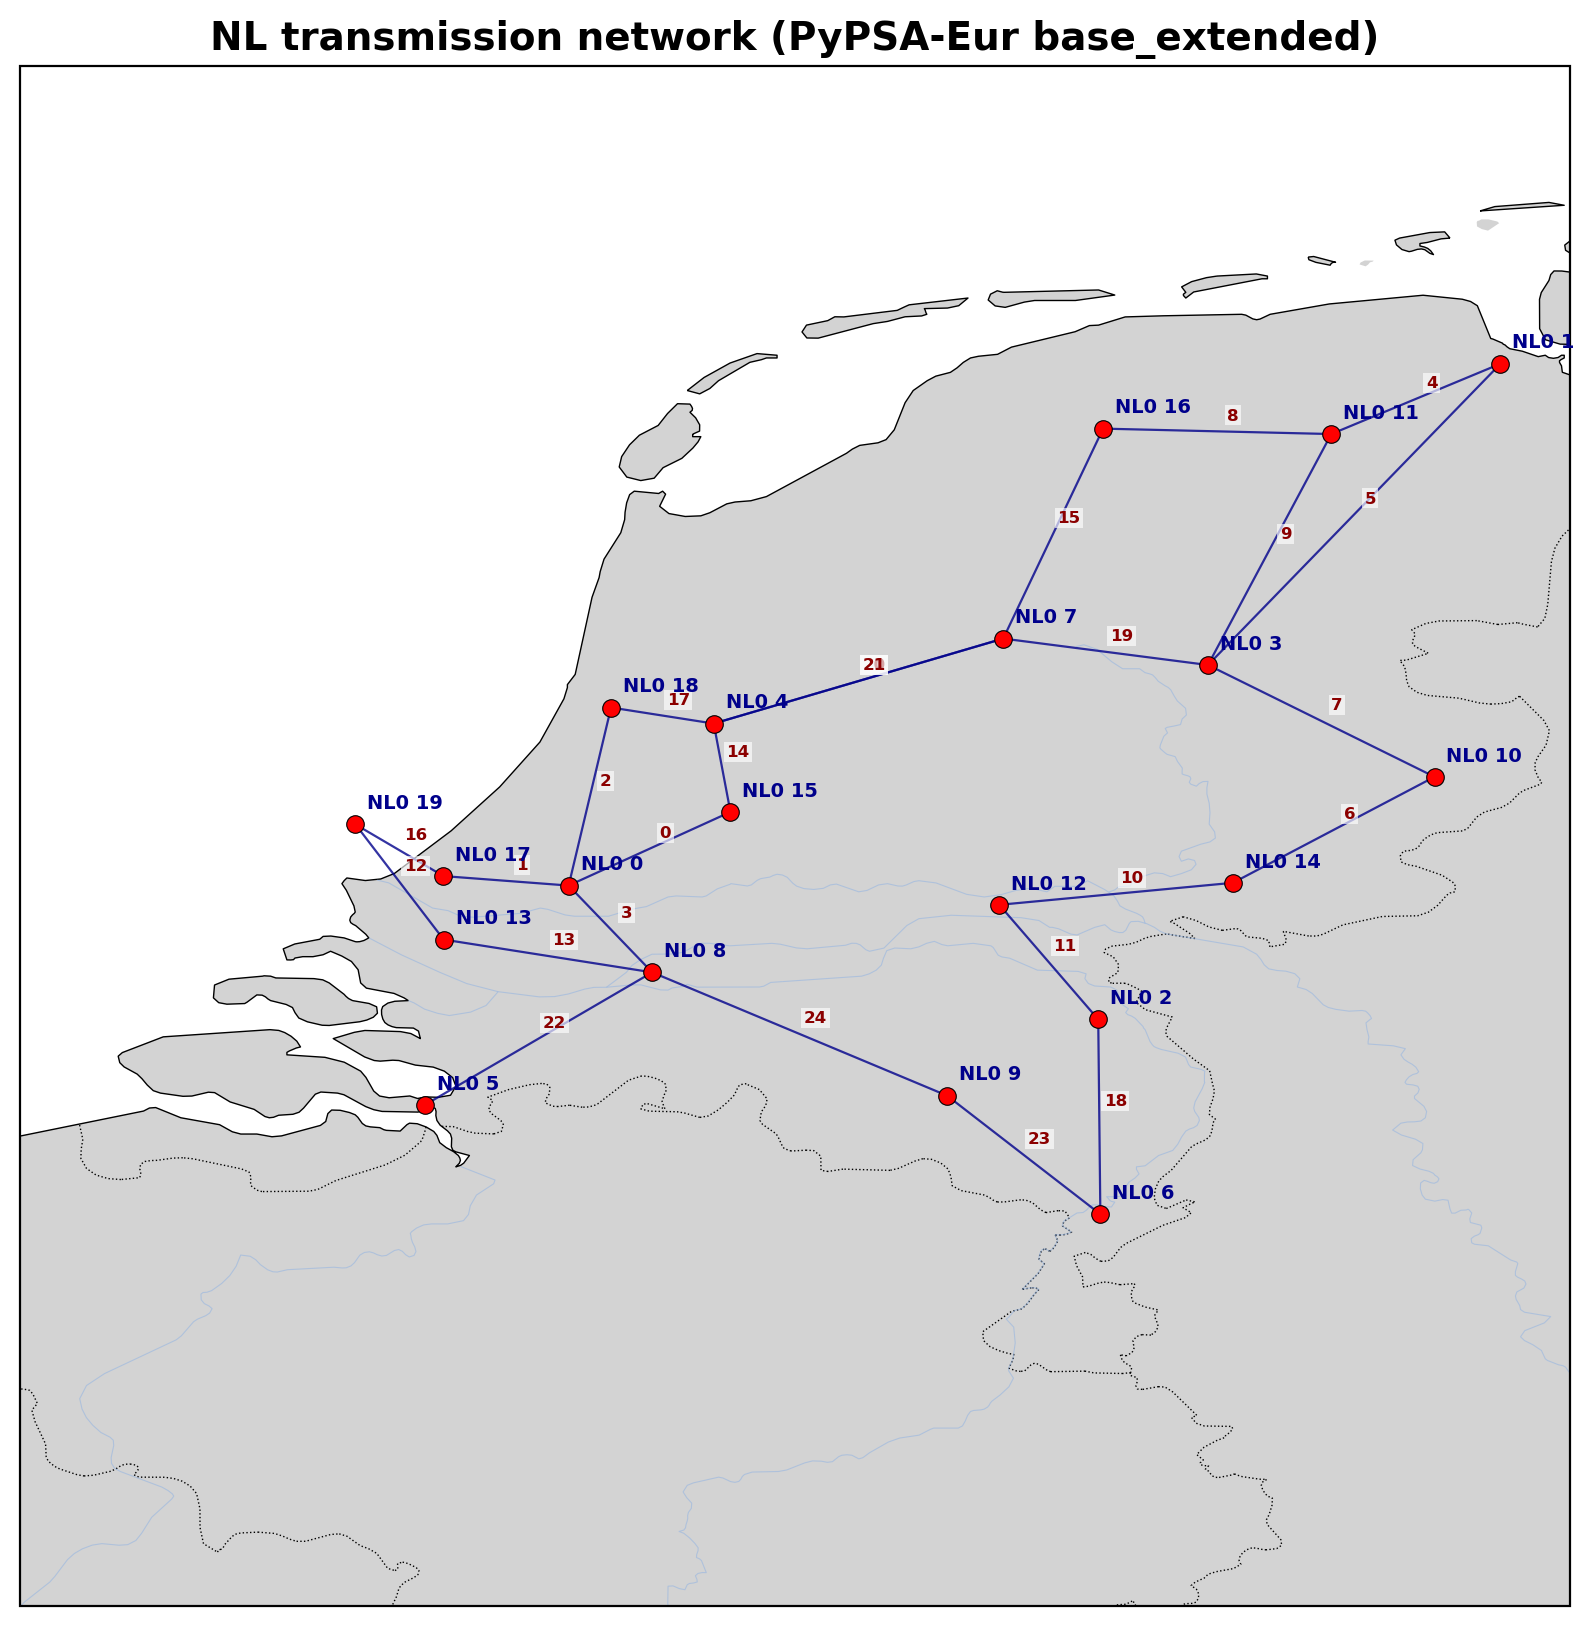

In [ ]:
b = n.buses

# no cross-border lines
nl_buses = b.index[b.country == "NL"]
lines_nl = n.lines.index[n.lines.bus0.isin(nl_buses) & n.lines.bus1.isin(nl_buses)]

fig, ax = plt.subplots(figsize=(10, 10), dpi=200, subplot_kw=dict(projection=ccrs.PlateCarree()))

# Netherlands background
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.RIVERS.with_scale('10m'), linewidth=0.4, alpha=0.6)

# NL extent (lon_min, lon_max, lat_min, lat_max) - tighter zoom to avoid Belgium
ax.set_extent([3.2, 7.1, 50.8, 53.4], crs=ccrs.PlateCarree())

# draw lines and name labels
for l in lines_nl:
    bus0 = n.lines.at[l, "bus0"]
    bus1 = n.lines.at[l, "bus1"]
    x0, y0 = n.buses.at[bus0, "x"], n.buses.at[bus0, "y"]
    x1, y1 = n.buses.at[bus1, "x"], n.buses.at[bus1, "y"]
    ax.plot([x0, x1], [y0, y1], color='darkblue', linewidth=0.8, alpha=0.8, transform=ccrs.PlateCarree())
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    label_dx, label_dy = 0.04, 0.04
    ax.text(xm + label_dx, ym + label_dy, l, fontsize=6, fontweight='bold', color='darkred',
            transform=ccrs.PlateCarree(), ha='center', va='center', zorder=6,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=0.9))

# draw buses and names
ax.scatter(n.buses.loc[nl_buses, "x"], n.buses.loc[nl_buses, "y"], s=40, color='red', edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree(), zorder=5)
for bus in nl_buses:
    x, y = n.buses.at[bus, "x"], n.buses.at[bus, "y"]
    # offset labels slightly to reduce overlap with markers
    dx, dy = 0.03, 0.03
    ax.text(x + dx, y + dy, bus, fontsize=7, fontweight='bold', color='darkblue', transform=ccrs.PlateCarree(), ha='left', va='bottom', zorder=6)

ax.set_title("NL transmission network (PyPSA-Eur base_extended)", fontsize=14, fontweight='bold')
ax.set_aspect('equal', adjustable='datalim')
plt.show()

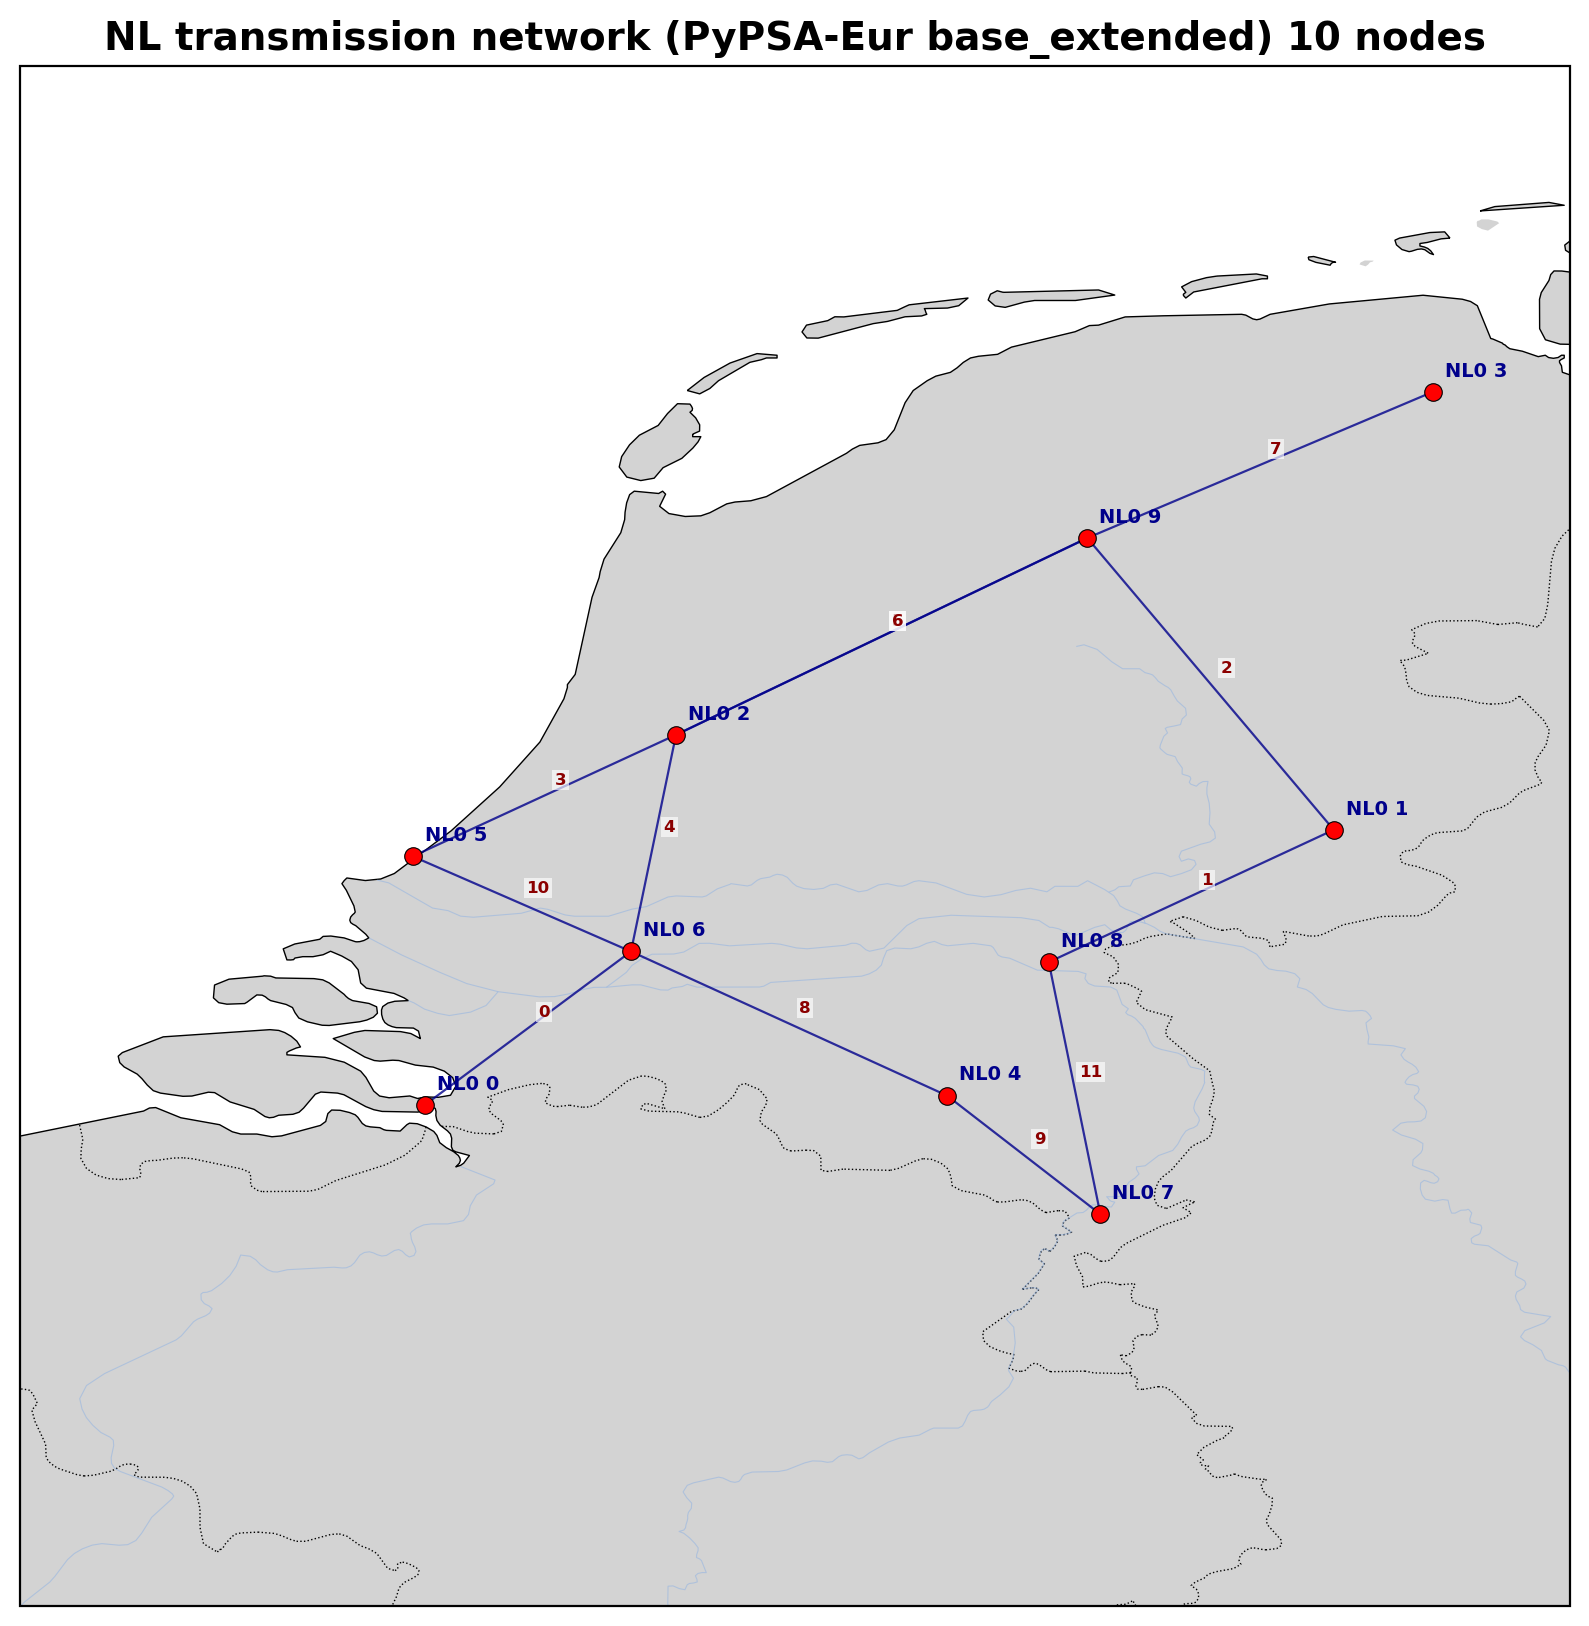

In [ ]:
b = n10.buses

# no cross-border lines
nl_buses = b.index[b.country == "NL"]
lines_nl = n10.lines.index[n10.lines.bus0.isin(nl_buses) & n10.lines.bus1.isin(nl_buses)]

fig, ax = plt.subplots(figsize=(10, 10), dpi=200, subplot_kw=dict(projection=ccrs.PlateCarree()))

# Netherlands background
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.RIVERS.with_scale('10m'), linewidth=0.4, alpha=0.6)

# NL extent (lon_min, lon_max, lat_min, lat_max) - tighter zoom to avoid Belgium
ax.set_extent([3.2, 7.1, 50.8, 53.4], crs=ccrs.PlateCarree())

# draw lines and name labels
for l in lines_nl:
    bus0 = n10.lines.at[l, "bus0"]
    bus1 = n10.lines.at[l, "bus1"]
    x0, y0 = n10.buses.at[bus0, "x"], n10.buses.at[bus0, "y"]
    x1, y1 = n10.buses.at[bus1, "x"], n10.buses.at[bus1, "y"]
    ax.plot([x0, x1], [y0, y1], color='darkblue', linewidth=0.8, alpha=0.8, transform=ccrs.PlateCarree())
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    label_dx, label_dy = 0.04, 0.04
    ax.text(xm + label_dx, ym + label_dy, l, fontsize=6, fontweight='bold', color='darkred',
            transform=ccrs.PlateCarree(), ha='center', va='center', zorder=6,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=0.9))

# draw buses and names
ax.scatter(n10.buses.loc[nl_buses, "x"], n10.buses.loc[nl_buses, "y"], s=40, color='red', edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree(), zorder=5)
for bus in nl_buses:
    x, y = n10.buses.at[bus, "x"], n10.buses.at[bus, "y"]
    # offset labels slightly to reduce overlap with markers
    dx, dy = 0.03, 0.03
    ax.text(x + dx, y + dy, bus, fontsize=7, fontweight='bold', color='darkblue', transform=ccrs.PlateCarree(), ha='left', va='bottom', zorder=6)

ax.set_title("NL transmission network (PyPSA-Eur base_extended) 10 nodes", fontsize=14, fontweight='bold')
ax.set_aspect('equal', adjustable='datalim')
plt.show()

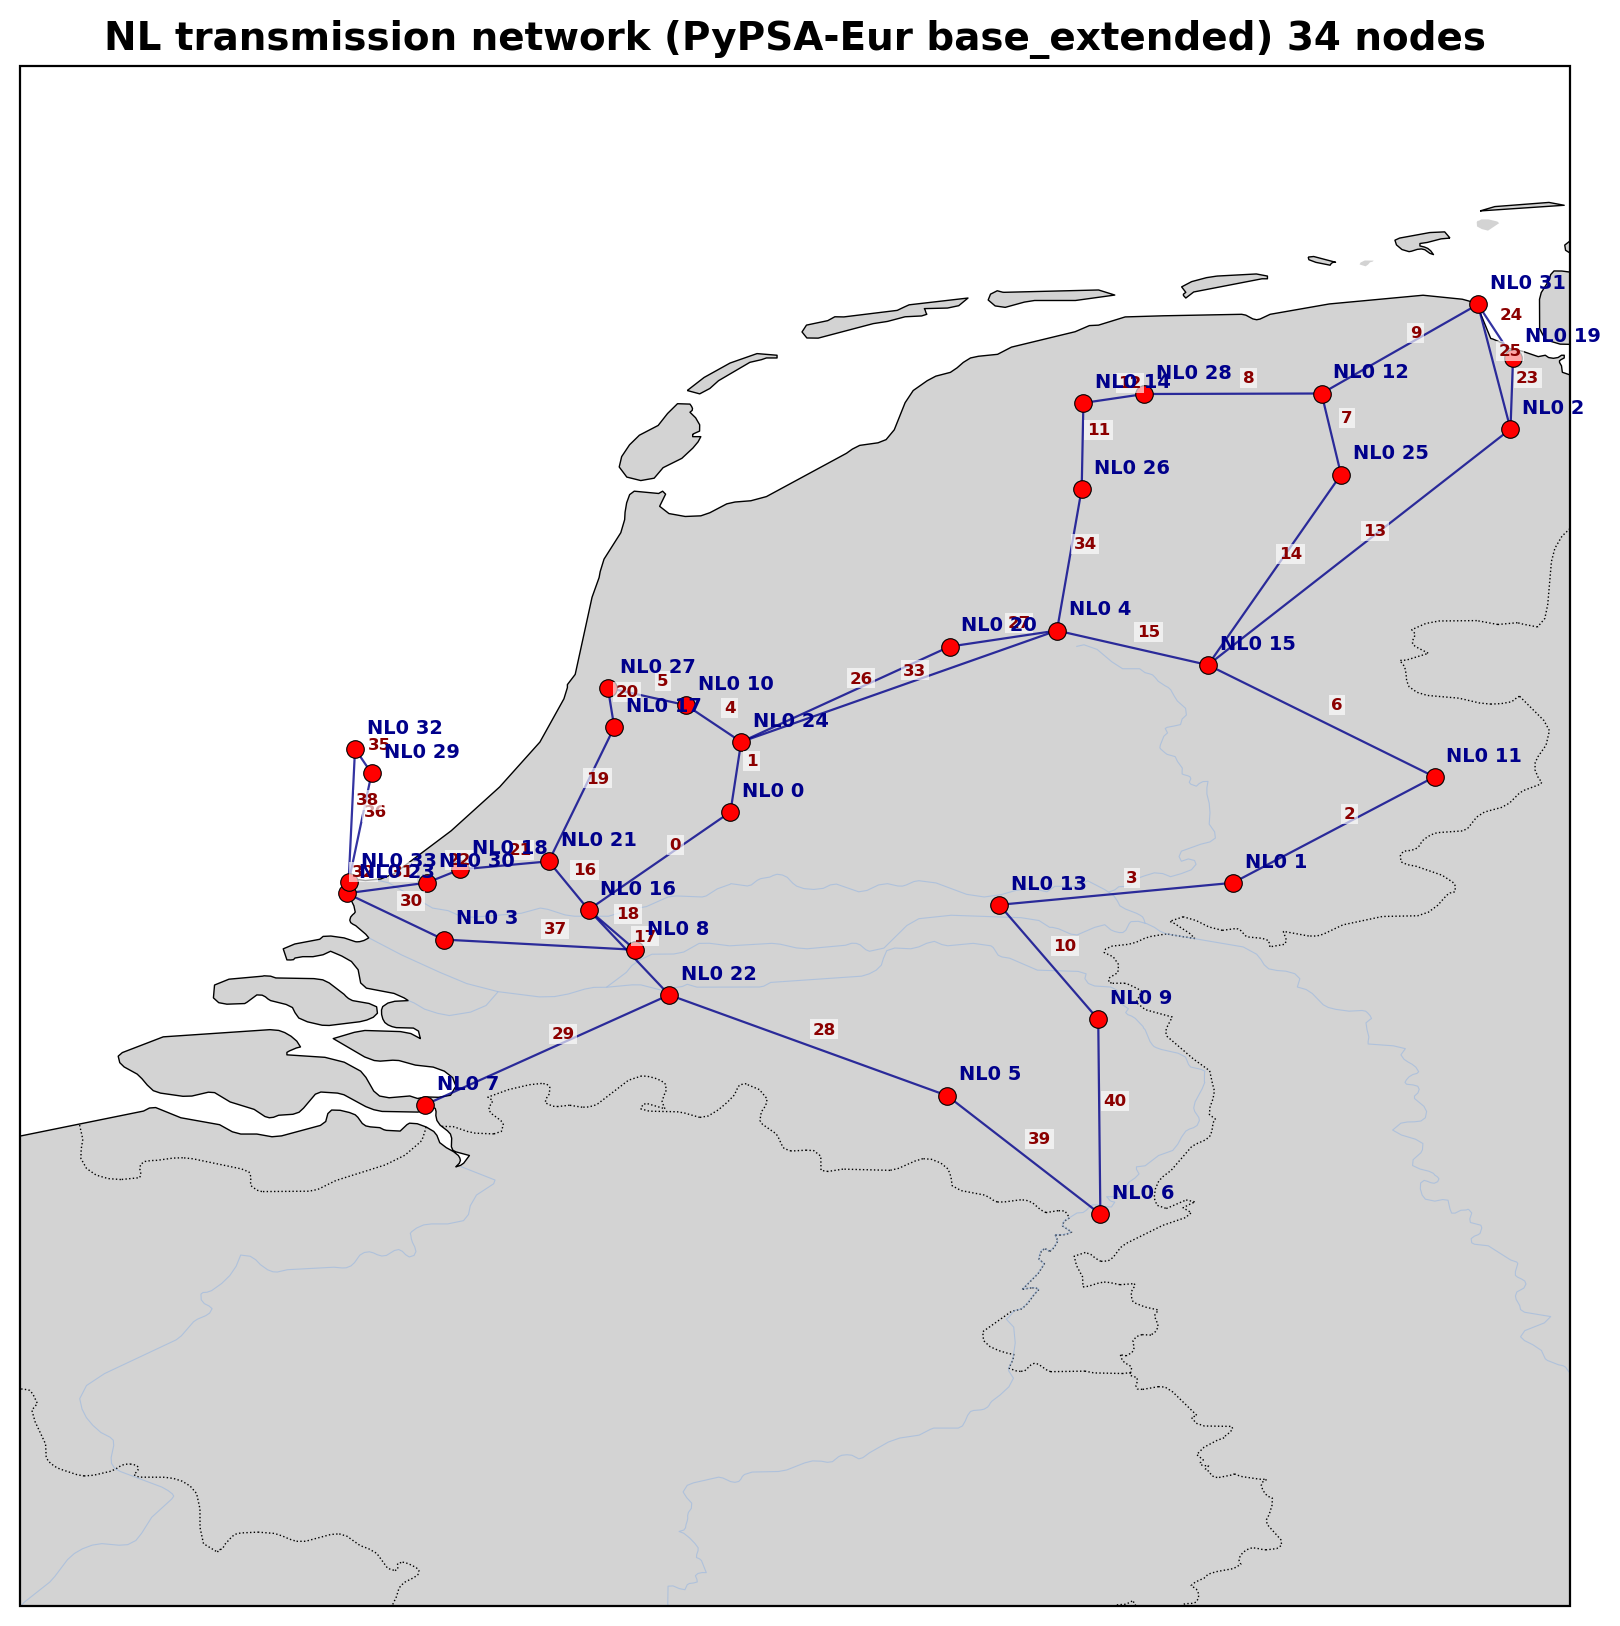

In [ ]:
c = n34.buses

# no cross-border lines
nl_buses = c.index[c.country == "NL"]
lines_nl = n34.lines.index[n34.lines.bus0.isin(nl_buses) & n34.lines.bus1.isin(nl_buses)]

fig, ax = plt.subplots(figsize=(10, 10), dpi=200, subplot_kw=dict(projection=ccrs.PlateCarree()))

# Netherlands background
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.RIVERS.with_scale('10m'), linewidth=0.4, alpha=0.6)

# NL extent (lon_min, lon_max, lat_min, lat_max) - tighter zoom to avoid Belgium
ax.set_extent([3.2, 7.1, 50.8, 53.4], crs=ccrs.PlateCarree())

# draw lines and name labels
for l in lines_nl:
    bus0 = n34.lines.at[l, "bus0"]
    bus1 = n34.lines.at[l, "bus1"]
    x0, y0 = n34.buses.at[bus0, "x"], n34.buses.at[bus0, "y"]
    x1, y1 = n34.buses.at[bus1, "x"], n34.buses.at[bus1, "y"]
    ax.plot([x0, x1], [y0, y1], color='darkblue', linewidth=0.8, alpha=0.8, transform=ccrs.PlateCarree())
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    label_dx, label_dy = 0.04, 0.04
    ax.text(xm + label_dx, ym + label_dy, l, fontsize=6, fontweight='bold', color='darkred',
            transform=ccrs.PlateCarree(), ha='center', va='center', zorder=6,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=0.9))

# draw buses and names
ax.scatter(n34.buses.loc[nl_buses, "x"], n34.buses.loc[nl_buses, "y"], s=40, color='red', edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree(), zorder=5)
for bus in nl_buses:
    x, y = n34.buses.at[bus, "x"], n34.buses.at[bus, "y"]
    # offset labels slightly to reduce overlap with markers
    dx, dy = 0.03, 0.03
    ax.text(x + dx, y + dy, bus, fontsize=7, fontweight='bold', color='darkblue', transform=ccrs.PlateCarree(), ha='left', va='bottom', zorder=6)

ax.set_title("NL transmission network (PyPSA-Eur base_extended) 34 nodes", fontsize=14, fontweight='bold')
ax.set_aspect('equal', adjustable='datalim')
plt.show()

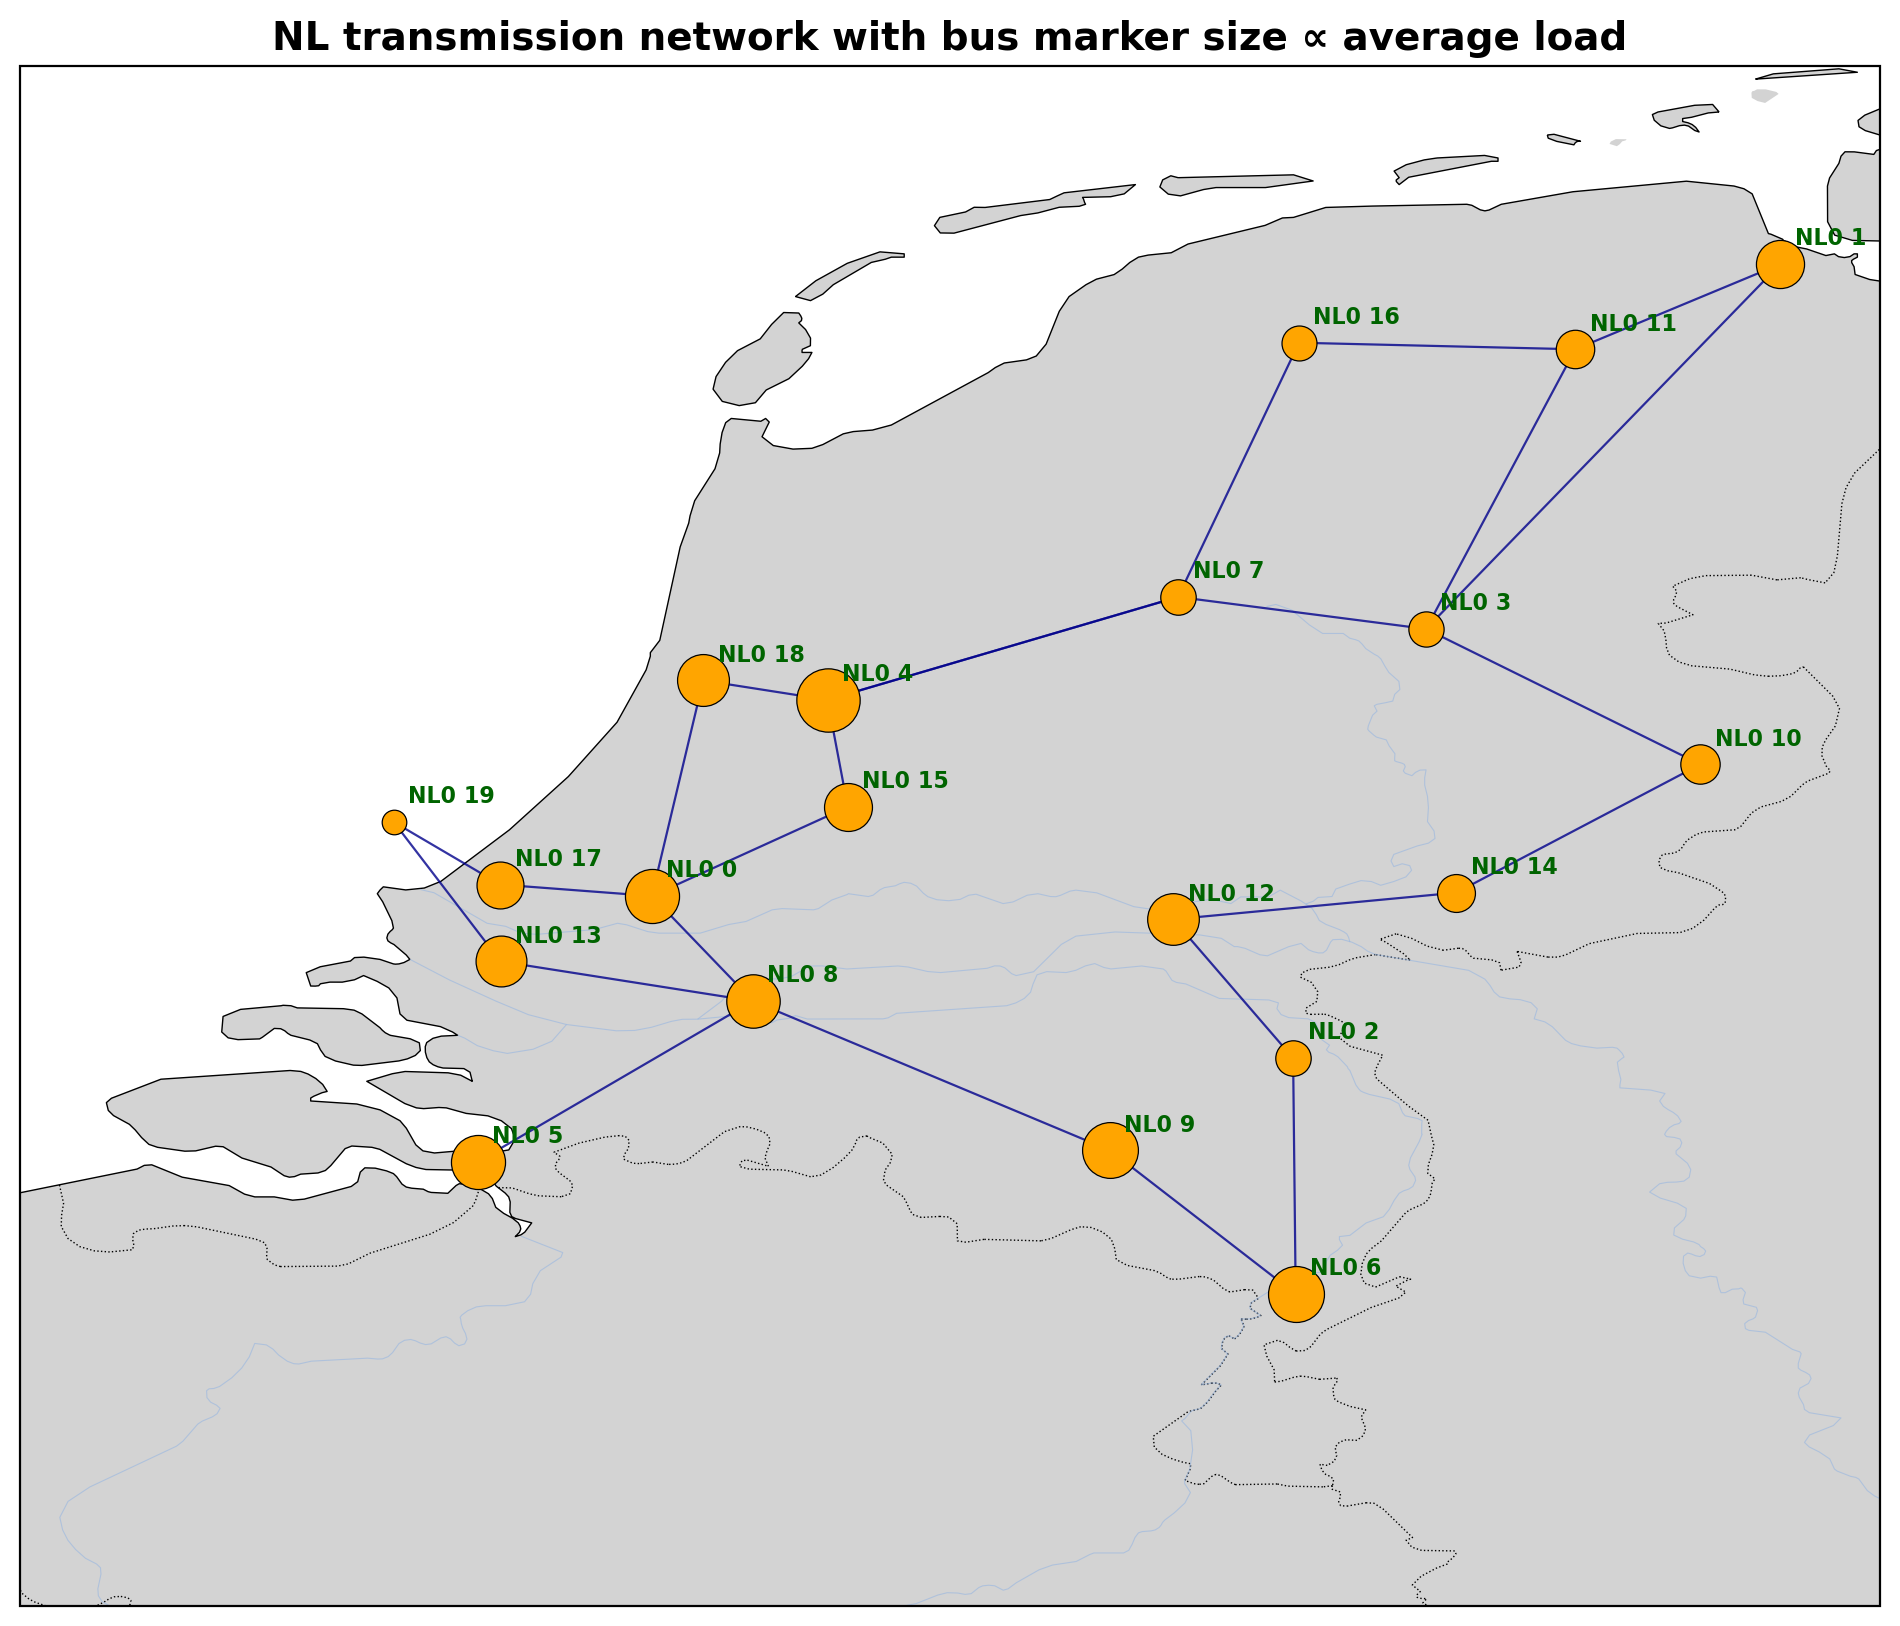

In [28]:
# New map: bus marker size proportional to peak load at each bus
fig, ax = plt.subplots(figsize=(12, 10), dpi=200, subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.RIVERS.with_scale('10m'), linewidth=0.4, alpha=0.6)
ax.set_extent([3.0, 7.4, 50.5, 53.7], crs=ccrs.PlateCarree())

# draw lines (same as before)
for l in lines_nl:
    bus0 = n.lines.at[l, "bus0"]
    bus1 = n.lines.at[l, "bus1"]
    x0, y0 = n.buses.at[bus0, "x"], n.buses.at[bus0, "y"]
    x1, y1 = n.buses.at[bus1, "x"], n.buses.at[bus1, "y"]
    ax.plot([x0, x1], [y0, y1], color='darkblue', linewidth=0.8, alpha=0.8, transform=ccrs.PlateCarree())

# compute average load per bus from load_per_bus time series
load = load_per_bus.mean(axis=0) if 'load_per_bus' in globals() else n.loads.groupby('bus')['p_set'].mean()
load_norm = (load / load.max()) * 500

# draw proportional bus markers
for bus in nl_buses:
    x, y = n.buses.at[bus, "x"], n.buses.at[bus, "y"]
    size = load_norm.get(bus, 20) + 20
    ax.scatter(x, y, s=size, color='orange', edgecolor='black', linewidth=0.45, transform=ccrs.PlateCarree(), zorder=6)
    ax.text(x + 0.03, y + 0.03, bus, fontsize=8, fontweight='bold', color='darkgreen', transform=ccrs.PlateCarree(), ha='left', va='bottom', zorder=7)

ax.set_title("NL transmission network with bus marker size ∝ average load", fontsize=14, fontweight='bold')
ax.set_aspect('equal', adjustable='datalim')
plt.show()

In [21]:
bus_load   = pd.read_csv('nl34_load_timeseries_per_bus.csv')
total_load = pd.read_csv('nl34_total_load_timeseries.csv')
 
bus_cols = [c for c in bus_load.columns if c != 'snapshot']
shares = bus_load[bus_cols].div(total_load['load'], axis=0)
mean_shares = shares.mean().sort_values(ascending=False)
cv = (shares.std() / shares.mean() * 100).fillna(0)
 
pick = [0, 3, 7, 14, 22, 29]
selected = [mean_shares.index[i] for i in pick]
colors = plt.cm.tab10(np.linspace(0, 1, len(selected)))
 
fig, ax = plt.subplots(figsize=(10, 4.5))
for bus, c in zip(selected, colors):
    ax.plot(shares[bus].values * 100, color=c, lw=0.7, alpha=0.85)
    ax.text(8760 + 80, mean_shares[bus] * 100,
            f'{bus} ({mean_shares[bus]*100:.1f}%)',
            va='center', fontsize=8, color=c)
 
ax.set_xlabel('Hour of Year', fontsize=11)
ax.set_ylabel('Nodal Load Share (%)', fontsize=11)
ax.set_title('Nodal Load as Fraction of Total System Load', fontsize=12)
ax.set_xlim(0, 8760)
ax.margins(y=0.05)
ax.text(0.35, 0.15, f'Max coefficient of variation: {cv.max():.4f}%\nShares are time-invariant',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
 
plt.tight_layout()
plt.subplots_adjust(right=0.82)
plt.savefig('repdays_8-unequal_weights\\load_share_validation.png', dpi=150)
 
print(f'Max CV:        {cv.max():.4f}%')
print(f'Max abs error: {(bus_load[bus_cols].values - np.outer(total_load["load"].values, mean_shares[bus_cols].values)).max():.6f} MW')
print(f'Shares sum:    {mean_shares.sum():.6f}')
 

Max CV:        0.0059%
Max abs error: 0.000006 MW
Shares sum:    1.000000


In [20]:
print(bus_load.shape)
print(total_load.shape)
print(total_load['load'].iloc[31])
print(bus_load[bus_cols].sum(axis=1).iloc[31])

(8760, 35)
(8760, 2)
12917.61750793457
12917.61750793457
